
В данном домашнем задании вам необходимо обучить языковую модель (не более 1B параметров) решать примеры на сложение как можно более длинных чисел.

**Ожидаемый результат.** Необходимо предоставить код, а также технический отчет, содержащий описание метода и используемых данных, оценку качества (точность сложения).

**Пояснения:**

1. Можно использовать любые предобученные модели, можно их файнтюнить, обучать с нуля, адаптировать любым другим способом или брать как есть. Главное, чтобы все использованные вами идеи, код или веса моделей были описаны в приложенном отчете со ссылкой на источник.

2. Мы ожидаем, что ваш код принимает на вход два числа (в виде строк их десятичной записи) и выдает ответ в любом человекочитаемом виде. Однако, если ваша модель работает с входом в виде предложения на естественном языке, это тоже нормально, главное, чтобы это было описано в отчете.

3. Можно оценить качество работы алгоритма, посчитав accuracy на случайных множествах чисел разной длины. Если вам кажется более подходящей другая метрика, мы примем ваше решение. Опишите вашу метрику и аргументируйте выбор в отчете.

**Подсказка:** в качестве ориентира можете использовать следующий репозиторий (https://github.com/liutiedong/goat). В нем реализована сборка датасета для обучения и самообучения.

### Разбаловка

- [2 балла] Сбор датасета для обучения.  
- [3 балла] Реализация скрипта модели.
- [3 балла] Создание обученной модели с качеством (100% на числах длины < 10).
- [2 баллов] Валидация модели.

Для валидации можно использовать и готовую языковую модель без получения баллов за третий пункт.

## imports

In [1]:
import os
import random
import numpy as np
from datasets import load_dataset
from unsloth import FastModel, FastLanguageModel, is_bfloat16_supported
import torch
from trl import SFTTrainer
from transformers import TrainingArguments, EarlyStoppingCallback
from dotenv import load_dotenv, dotenv_values
import wandb
import weave

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

max_seq_length = 2048

load_dotenv()
hf_token  = dotenv_values().get("HF_TOKEN")
wandb_key = dotenv_values().get("WANDB_API_KEY")


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [2]:
# Возьмем готовый датасет. Отфильтруем по операции сложения.
goat_ds = load_dataset("tiedong/goat")

In [3]:
goat_ds

DatasetDict({
    train: Dataset({
        features: ['instruction', 'output', 'answer', 'input'],
        num_rows: 1746300
    })
})

In [4]:
goat_ds["train"][0]

{'instruction': '530991+6051993',
 'output': '530991 + 6051993 = 6582984',
 'answer': '6582984',
 'input': '530991 + 6051993'}

In [5]:
# Фильтруем датасет по условию: в поле input должен быть символ '+'
addition_ds = goat_ds['train'].filter(lambda x: '+' in x['input'])


In [6]:
addition_ds[-123]

{'instruction': 'Determine 33473 plus 432195868387250',
 'output': '33473 + 432195868387250 = 432195868420723',
 'answer': '432195868420723',
 'input': '33473 + 432195868387250'}

In [7]:
# Разделяем датасет на train 80%, test 10%, val 10%
train_test_split = addition_ds.train_test_split(
    test_size=0.2, seed=SEED, shuffle=True
)
val_test_split = train_test_split['test'].train_test_split(
    test_size=0.984, seed=SEED, shuffle=True,
)
train_ds = train_test_split['train']  # 80%
test_ds = val_test_split['test']      # 10%
val_ds = val_test_split['train']      # 10%
   
print(
    f"train: {train_ds.shape}\n"
    f"test : {test_ds.shape}\n"
    f"val  : {val_ds.shape}\n"
)   

train: (243200, 4)
test : (59828, 4)
val  : (972, 4)



## Model

In [8]:
model_name = "unsloth/Qwen3-0.6B"
# model, tokenizer = FastModel.from_pretrained(
pt_model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=model_name,
    # max_seq_length: Controls context length. While Qwen3 supports 40960, we 
    # recommend 2048 for testing. Unsloth enables 8× longer context fine-tuning
    max_seq_length=max_seq_length,    
    dtype=None,
    load_in_4bit=True,      # 4 bit quantization to reduce memory
    load_in_8bit=False,     # A bit more accurate, uses 2x memory
    full_finetuning=False,  
    token =hf_token,
)

==((====))==  Unsloth 2025.11.1: Fast Qwen3 patching. Transformers: 4.57.1.
   \\   /|    NVIDIA GeForce RTX 3080. Num GPUs = 1. Max memory: 9.64 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu128. CUDA: 8.6. CUDA Toolkit: 12.8. Triton: 3.5.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.33.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


In [9]:
print(f"is_bfloat16_supported: {is_bfloat16_supported()}")
model = FastLanguageModel.get_peft_model(
    pt_model,
    r=16,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=SEED,
    use_rslora=False,
    loftq_config=None,
)



is_bfloat16_supported: True


Unsloth 2025.11.1 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


In [10]:
def formatting_prompts_func(examples):
    instructions = examples["instruction"]
    inputs = examples["input"]
    outputs = examples["output"]
    texts = []
    for instruction, input_text, output in zip(instructions, inputs, outputs):
        if input_text.strip():
            user_message = f"{instruction}\n\n{input_text}"
        else:
            user_message = instruction
        messages = [
            {"role": "user", "content": user_message},
            {"role": "assistant", "content": output},
        ]
        text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False,
            enable_thinking=False
        )
        texts.append(text)
    return {"text": texts}


In [11]:
train_ds = train_ds.map(formatting_prompts_func, batched=True, num_proc=10)
test_ds = test_ds.map(formatting_prompts_func, batched=True, num_proc=10)
val_ds = val_ds.map(formatting_prompts_func, batched=True, num_proc=10)

## Training


In [12]:
trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    dataset_text_field="text",
    max_seq_length=max_seq_length,
    dataset_num_proc=2,
    packing=False,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=3, early_stopping_threshold=0.001
        )
    ],
    args=TrainingArguments(
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        warmup_steps=5,
        max_steps=300,
        learning_rate=2e-4,
        fp16=False,  # Выбираем bf16
        bf16=True,   # Выбираем bf16
        logging_steps=1,
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="linear",
        seed=SEED,  
        output_dir="outputs",
        report_to="wandb",
        # Validation
        fp16_full_eval=True,
        per_device_eval_batch_size=8,
        eval_strategy="steps",              # Evaluate every N steps
        eval_steps=10,                      # Evaluate every 10 steps
        save_strategy="steps",              # Save checkpoints every N steps
        save_steps=10,                      # Align with eval_steps
        load_best_model_at_end=True,        # Load best checkpoint at end
        metric_for_best_model="eval_loss",  # Use eval loss to find best
        save_total_limit=3,                 # Only keep 3 best checkpoints
    ),
)

In [13]:
# Если Unsloth был скомпилирован без wandb. Чистим его кэш, он будет сбилден заного.
#!rm -rf /home/rin/project/ml-modern/homework/hw05/unsloth_compiled_cache

In [14]:
wandb.login(key=wandb_key)
wandb.init(project="ml-modern-hw05")

trainer.train()

model.save_pretrained("final_lora_adapter")
tokenizer.save_pretrained("final_lora_adapter")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /home/rin/.netrc
wandb: Currently logged in as: lev-370x (lev-370x-home) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Initializing weave.
weave: Logged in as Weights & Biases user: lev-370x.
weave: View Weave data at https://wandb.ai/lev-370x-home/ml-modern-hw05/weave
[weave.trace.init_message|INFO]Logged in as Weights & Biases user: lev-370x.
View Weave data at https://wandb.ai/lev-370x-home/ml-modern-hw05/weave
The model is already on multiple devices. Skipping the move to device specified in `args`.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 243,200 | Num Epochs = 1 | Total steps = 300
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 10,092,544 of 606,142,464 (1.67% trained)


Step,Training Loss,Validation Loss
10,1.282800,1.210915
20,0.953600,0.877679
30,0.770400,0.742118
40,0.701500,0.697864
50,0.700200,0.695464
60,0.714000,0.672345
70,0.679900,0.659410
80,0.642200,0.660858
90,0.662200,0.650267
100,0.640200,0.642318


Unsloth: Not an error, but Qwen3ForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


('final_lora_adapter/tokenizer_config.json',
 'final_lora_adapter/special_tokens_map.json',
 'final_lora_adapter/chat_template.jinja',
 'final_lora_adapter/vocab.json',
 'final_lora_adapter/merges.txt',
 'final_lora_adapter/added_tokens.json',
 'final_lora_adapter/tokenizer.json')

In [15]:
# model.save_pretrained("final_lora_adapter")
# tokenizer.save_pretrained("final_lora_adapter")

---

In [26]:
import wandb
import matplotlib.pyplot as plt

# Initialize API
api = wandb.Api()

# Get a specific run
run_name = "lev-370x-home/ml-modern-hw05/bkfuu5a9"
# run_name = "snowy-fire-6"
# run_name = "lev-370x-home/ml-modern-hw05/bkfuu5a9/snowy-fire-6"
run = api.run(run_name)

# Get history data
history = run.history()

# See all available columns
print(history.columns.tolist())

# Or view the first few rows
print(history.head())


['train/epoch', 'train/grad_norm', 'train/learning_rate', 'eval/samples_per_second', 'train/global_step', 'eval/steps_per_second', 'eval/loss', '_timestamp', 'train/loss', 'eval/runtime', '_step', '_runtime']
   train/epoch  train/grad_norm  train/learning_rate  eval/samples_per_second  \
0     0.000033         3.324033              0.00000                      NaN   
1     0.000066         3.824123              0.00004                      NaN   
2     0.000099         3.675245              0.00008                      NaN   
3     0.000132         3.213039              0.00012                      NaN   
4     0.000164         2.407187              0.00016                      NaN   

   train/global_step  eval/steps_per_second  eval/loss    _timestamp  \
0                  1                    NaN        NaN  1.763925e+09   
1                  2                    NaN        NaN  1.763925e+09   
2                  3                    NaN        NaN  1.763925e+09   
3               

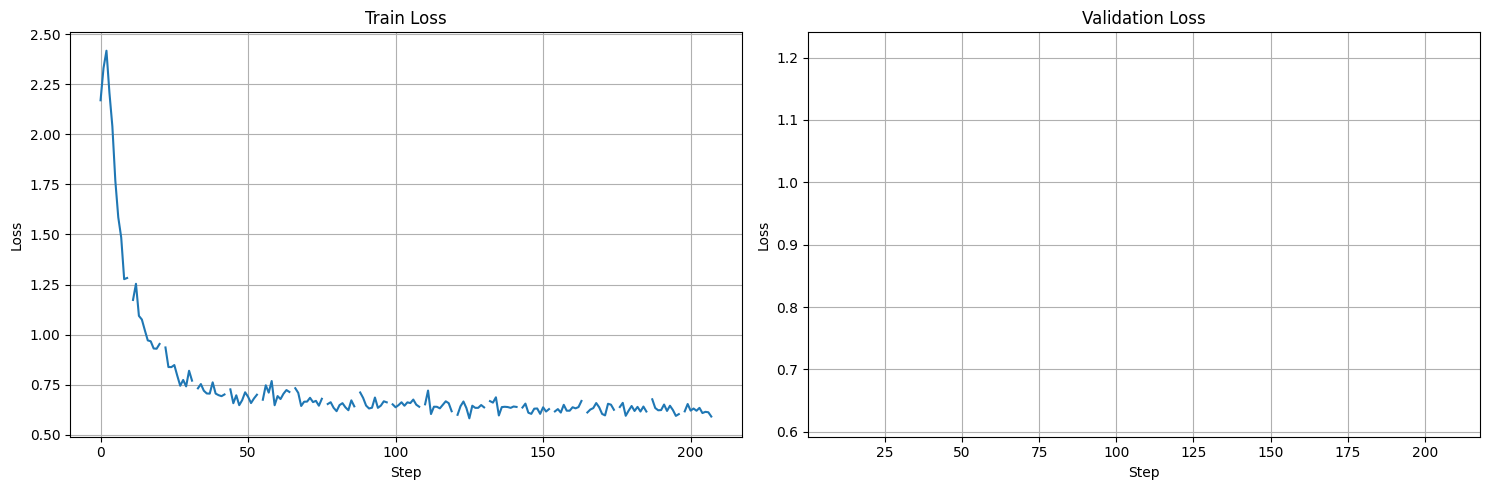

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history["train/loss"])
axes[0].set_title("Train Loss")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].grid(True)

# Validation Loss
axes[1].plot(history["eval/loss"], color='orange')
axes[1].set_title("Validation Loss")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Loss")
axes[1].grid(True)

plt.tight_layout()
plt.show()

Почему-то не подгружается график val loss

## Валидация

In [ ]:
# # Загрузка сохраненной модели (LoRA адаптера)
# from unsloth import FastLanguageModel
# from peft import PeftModel

# # Load base model
# base_model, tokenizer = FastLanguageModel.from_pretrained(
#     model_name="unsloth/Qwen3-0.6B",
#     max_seq_length=2048,
#     load_in_4bit=True,
# )

# # Load saved LoRA adapter
# model = PeftModel.from_pretrained(base_model, "final_lora_adapter")
# FastLanguageModel.for_inference(model)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2025.11.1: Fast Qwen3 patching. Transformers: 4.57.1.
   \\   /|    NVIDIA GeForce RTX 3080. Num GPUs = 1. Max memory: 9.64 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu128. CUDA: 8.6. CUDA Toolkit: 12.8. Triton: 3.5.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.33.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen3ForCausalLM(
      (model): Qwen3Model(
        (embed_tokens): Embedding(151936, 1024, padding_idx=151654)
        (layers): ModuleList(
          (0): Qwen3DecoderLayer(
            (self_attn): Qwen3Attention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=1024, out_features=2048, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Identity()
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=1024, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora.Linear(
      

In [2]:
FastLanguageModel.for_inference(model)

user_query = "Add two numbers 1000 and 30000"
messages = [
    {"role": "user", "content": user_query},
]
prompt = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=False,
)
inputs = tokenizer([prompt], return_tensors="pt").to("cuda")
outputs = model.generate(
    **inputs,
    max_new_tokens=128,
    do_sample=True,
    use_cache=False,
    # temperature=0.7,
    # top_p=0.8,
    # top_k=20,
    # min_p=0.0,
)


print(tokenizer.decode(outputs[0], skip_special_tokens=True))


user
Add two numbers 1000 and 30000
assistant
<think>

</think>

1000 + 30000 = 31000


In [6]:
import re
import random


def compute_exact_match_accuracy(predictions, references):
    correct = sum(
        1 for pred, ref in zip(predictions, references) 
        if pred.strip() == ref.strip()
    )
    return correct / len(predictions)


def create_stratified_test_set(max_length=100, samples_per_length=100):
    test_cases = []
    
    for length in range(1, max_length + 1):
        for _ in range(samples_per_length):
            num1 = random.randint(10**(length-1), 10**length - 1)
            num2 = random.randint(10**(length-1), 10**length - 1)
            test_cases.append({
                'num1': str(num1),
                'num2': str(num2),
                'answer': str(num1 + num2),
                'length': length
            })
    
    return test_cases



def extract_answer(generated_text):
    # "= 31000" or "answer is 31000"
    patterns = [
        r'=\s*(\d+)',
        r'answer\s*is\s*(\d+)',
        r'(\d+)\s*$',  # Last number in the output
    ]
    
    for pattern in patterns:
        match = re.search(pattern, generated_text, re.IGNORECASE)
        if match:
            return match.group(1)
    
    return ""

In [ ]:
import evaluate
import numpy as np

def comprehensive_evaluation(model, tokenizer, test_dataset):
    predictions = []
    references = []
    
    FastLanguageModel.for_inference(model)
    
    for example in test_dataset:
        # Format prompt
        user_query = f"Calculate {example['num1']} + {example['num2']}"
        messages = [{"role": "user", "content": user_query}]
        prompt = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
            enable_thinking=False
        )
        
        inputs = tokenizer([prompt], return_tensors="pt").to("cuda")
        
        outputs = model.generate(
            **inputs,
            max_new_tokens=128,
            do_sample=False,  # Deterministic for evaluation
            temperature=1.0,
        )
        
        # Extract answer from output
        generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
        predicted_answer = extract_answer(generated_text)
        
        predictions.append(predicted_answer)
        references.append(example['answer'])
    
    # Compute metrics
    accuracy = sum(p == r for p, r in zip(predictions, references)) / len(predictions)
    
    return {
        'exact_match_accuracy': accuracy,
        'total_examples': len(predictions),
        'correct': sum(p == r for p, r in zip(predictions, references))
    }

In [7]:
short_test = create_stratified_test_set(max_length=9, samples_per_length=100)
short_results = comprehensive_evaluation(model, tokenizer, short_test)
print(f"Accuracy on length < 10: {short_results['exact_match_accuracy']:.2%}")

Accuracy on length < 10: 90.56%


In [9]:
long_test = create_stratified_test_set(max_length=50, samples_per_length=20)
long_results = comprehensive_evaluation(model, tokenizer, long_test)
print(f"Accuracy on length < 50: {long_results['exact_match_accuracy']:.2%}")

Accuracy on length < 50: 23.60%


## Gradio

In [15]:
import gradio as gr

def add_with_model(num1, num2):
    user_query = f"Calculate {num1} + {num2}"
    messages = [{"role": "user", "content": user_query}]
    
    prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True, enable_thinking=False
    )
    
    inputs = tokenizer([prompt], return_tensors="pt").to("cuda")
    outputs = model.generate(**inputs, max_new_tokens=128, do_sample=False)
    
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

demo = gr.Interface(
    fn=add_with_model,
    inputs=[gr.Textbox(label="Число 1"), gr.Textbox(label="Число 2")],
    outputs=gr.Textbox(label="Результат"),
    title="Сложение чисел"
)

demo.launch(share=True)  

* Running on local URL:  http://127.0.0.1:7862
* Running on public URL: https://7c40b09d67f4bfb60d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Описание решения

1. Взят готовый датасет. Отфильтрован по операции сложения.
2. Выбрана модель Qwen3-0.6B, подходит по параметрам и довольно свежая модель. 
    А также опыт FT Qwen3 мне пригодиться в ближайшее время.
3. Проведен FT LoRA с помощью фреймворка unsloth.
    Ни разу им не пользовался, но часто про него слышу. 
    - Ссылка на wandb: https://wandb.ai/lev-370x-home/ml-modern-hw05/workspace?nw=nwuserlev370x
4. Для валидации модели accuracy считается по полному совпадению ответа с правильным ответом.
    - На тестах с числами длины < 10 accuracy 90.56%
    - На тестах с числами длины < 50 accuracy 23.60%
5. Произведен запуск модели на gradio.

---

Python version
```shell
(ml-modern-hw05) rin@blanco:~/project/ml-modern/homework/hw05$ python -V
Python 3.12.10

```

uv pyproject.toml
```toml
[project]
name = "hw05"
version = "0.1.0"
requires-python = ">=3.12"
dependencies = [
    "datasets>=4.4.1",
    "dotenv>=0.9.9",
    "evaluate>=0.4.6",
    "gradio>=5.50.0",
    "huggingface-hub<0.36.0",
    "ipykernel>=7.1.0",
    "ipywidgets>=8.1.8",
    "unsloth>=2025.11.1",
    "unsloth-zoo>=2025.11.2",
    "wandb>=0.23.0",
    "weave>=0.52.17",
]
```


requirements.txt
```text
abnf==2.2.0
accelerate==1.11.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.2
aiosignal==1.4.0
annotated-doc==0.0.4
annotated-types==0.7.0
anyio==4.11.0
asttokens==3.0.1
attrs==25.4.0
backoff==2.2.1
bitsandbytes==0.48.2
brotli==1.2.0
certifi==2025.11.12
cffi==2.0.0
chardet==5.2.0
charset-normalizer==3.4.4
cint==1.0.0
click==8.3.1
comm==0.2.3
cryptography==46.0.3
cut-cross-entropy==25.1.1
datasets==4.4.1
debugpy==1.8.17
decorator==5.2.1
diffusers==0.35.2
dill==0.4.0
diskcache==5.6.3
docstring-parser==0.17.0
dotenv==0.9.9
eval-type-backport==0.3.0
evaluate==0.4.6
executing==2.2.1
fastapi==0.121.3
ffmpy==1.0.0
fickling==0.1.5
filelock==3.20.0
frozenlist==1.8.0
fsspec==2025.10.0
gitdb==4.0.12
gitpython==3.1.45
gql==4.0.0
gradio==5.50.0
gradio-client==1.14.0
graphql-core==3.2.7
graphviz==0.21
groovy==0.1.2
h11==0.16.0
hf-transfer==0.1.9
hf-xet==1.2.0
httpcore==1.0.9
httpx==0.28.1
huggingface-hub==0.35.3
idna==3.11
importlib-metadata==8.7.0
intervaltree==3.1.0
ipykernel==7.1.0
ipython==9.7.0
ipython-pygments-lexers==1.1.1
ipywidgets==8.1.8
jedi==0.19.2
jinja2==3.1.6
jsonschema==4.25.1
jsonschema-specifications==2025.9.1
jupyter-client==8.6.3
jupyter-core==5.9.1
jupyterlab-widgets==3.0.16
kaitaistruct==0.11
markdown-it-py==4.0.0
markupsafe==3.0.3
matplotlib-inline==0.2.1
mdurl==0.1.2
mpmath==1.3.0
msgspec==0.19.0
multidict==6.7.0
multiprocess==0.70.18
nest-asyncio==1.6.0
networkx==3.5
numpy==2.3.5
nvidia-cublas-cu12==12.8.4.1
nvidia-cuda-cupti-cu12==12.8.90
nvidia-cuda-nvrtc-cu12==12.8.93
nvidia-cuda-runtime-cu12==12.8.90
nvidia-cudnn-cu12==9.10.2.21
nvidia-cufft-cu12==11.3.3.83
nvidia-cufile-cu12==1.13.1.3
nvidia-curand-cu12==10.3.9.90
nvidia-cusolver-cu12==11.7.3.90
nvidia-cusparse-cu12==12.5.8.93
nvidia-cusparselt-cu12==0.7.1
nvidia-nccl-cu12==2.27.5
nvidia-nvjitlink-cu12==12.8.93
nvidia-nvshmem-cu12==3.3.20
nvidia-nvtx-cu12==12.8.90
orjson==3.11.4
packaging==25.0
pandas==2.3.3
parso==0.8.5
pdfminer-six==20250506
peft==0.18.0
pexpect==4.9.0
pillow==11.3.0
platformdirs==4.5.0
polyfile-weave==0.5.7
prompt-toolkit==3.0.52
propcache==0.4.1
protobuf==6.33.1
psutil==7.1.3
ptyprocess==0.7.0
pure-eval==0.2.3
pyarrow==22.0.0
pycparser==2.23
pydantic==2.12.3
pydantic-core==2.41.4
pydub==0.25.1
pygments==2.19.2
python-dateutil==2.9.0.post0
python-dotenv==1.2.1
python-multipart==0.0.20
pytz==2025.2
pyyaml==6.0.3
pyzmq==27.1.0
referencing==0.37.0
regex==2025.11.3
requests==2.32.5
requests-toolbelt==1.0.0
rich==14.2.0
rpds-py==0.29.0
ruff==0.14.6
safehttpx==0.1.7
safetensors==0.7.0
semantic-version==2.10.0
sentencepiece==0.2.1
sentry-sdk==2.45.0
setuptools==80.9.0
shellingham==1.5.4
shtab==1.8.0
six==1.17.0
smmap==5.0.2
sniffio==1.3.1
sortedcontainers==2.4.0
stack-data==0.6.3
starlette==0.50.0
stdlib-list==0.11.1
sympy==1.14.0
tenacity==9.1.2
tokenizers==0.22.1
tomlkit==0.13.3
torch==2.9.0
torchao==0.14.1
torchvision==0.24.0
tornado==6.5.2
tqdm==4.67.1
traitlets==5.14.3
transformers==4.57.1
triton==3.5.0
trl==0.23.0
typeguard==4.4.4
typer==0.20.0
typer-slim==0.20.0
typing-extensions==4.15.0
typing-inspection==0.4.2
tyro==0.9.35
tzdata==2025.2
unsloth==2025.11.1
unsloth-zoo==2025.11.2
urllib3==2.5.0
uvicorn==0.38.0
wandb==0.23.0
wcwidth==0.2.14
weave==0.52.17
websockets==15.0.1
wheel==0.45.1
widgetsnbextension==4.0.15
xformers==0.0.33.post1
xxhash==3.6.0
yarl==1.22.0
zipp==3.23.0
```